# Colerectal Cancer (CRC) Fusion-Gene Analysis
1. Collate the Arriba fusion results for every library, across the 3 datasets
2. Are the same fusions found in all replicates, and in treatment vs control?
3. Comparative genomics: compare fusions bound in human vs vs mouse
4. Compare the fusions detected with bulk RNA-seq (Arriba) and long reads (Sun et al. Table S6)

Arriba is a tool that scans RNA-seq reads and predict these fusions. Each dataset is a folder of .tsv tables: one table per sequenced library/sample

## Preprocessing
Librarires used:
* pandas
* matplotlib
* os
* glob
* re

In [50]:
# Import libraries
import pandas as pd     # dataframes
import matplotlib.pyplot as plt   # plotting
import os               # universal filepaths
import re               # regular expressions
import glob             # files searching
from pathlib import Path    # Type annotations

# Data directories
# Data is stored in folder before repo in <parent>/Data/Arriba results
# os.path.join combines path together with the correct slash/separators for the OS; ".." goes up one folder
# Notebook should be in src/CRC
Data_Dir = os.path.join("..", "..", "..", "Data", "Arriba results")
Suppl_Dir = os.path.join("..", "..", "..", "Data", "Supp_tables_fusion_events.xlsx")
Results_Dir = os.path.join("..", "..", "results")

# Sanity checks
print(f"Arriba data is in: {os.path.abspath(Data_Dir)}\nSupplementary sheet is in: {os.path.abspath(Suppl_Dir)}")
print(f"Arriba data exists?: {os.path.isdir(Data_Dir)}\nSupplementary data exists?: {os.path.isfile(Suppl_Dir)}")


Arriba data is in: /Users/almarcastorga/Documents/5th Year MSc Bioinformatics/Fusion Gene Hackathon/Data/Arriba results
Supplementary sheet is in: /Users/almarcastorga/Documents/5th Year MSc Bioinformatics/Fusion Gene Hackathon/Data/Supp_tables_fusion_events.xlsx
Arriba data exists?: True
Supplementary data exists?: True


### Data tidying functions
- Arriba gene2 column sometimes has two genes inside it e.g. (Gm18582(33168),Gm48918(208887)). This occurs when the breakpoints are between two genes. Decide to drop one or the other and the numbers
- Extract the experiment condition from each sample name

In [51]:
def clean_gene(name: str) -> str:
    """
    Return a clean singular gene ID from Arriba gene2 column
    - regex to remove all bracketed digits
    - .split to only keep the text 
    """
    name = str(name)
    name = re.sub(r"\(\d+\)", "", name)     # remove "(123)"" bracketed numbers
    name = name.split(",")[0]
    return name.strip()

def condition(sample_name:str) -> str:
    """
    Extract the experiment condition from a library/sample
    - IFN_1 = IFN
    - ctrl_2 = ctrl
    - organoid_GC_3 = GCA
    - KRAS_organoids_antiEGFR_1 = antiEGFR
    """
    name = sample_name
    # Remove dataset specific prefixes not part of the condition
    name = name.replace("KRAS_organioids_", "")
    name = name.replace("organoid_", "")
    # Remove replicate number
    name = re.sub(r"_\d+$", "", name)
    return name

## Collate every library/sample onto one
Reading every Arriba .tsv file from all three datasets and stack them. Adding columns stating which dataset, library/sample and condition each fusion came from.

In [52]:
Datasets = { "mouse_ifn":   "PRJNA1062304_arriba_mouse_ifn",
            "human_bile":   "PRJNA1269539_arriba_human_bile_salts",
            "human_antiEGFR":   "PRJNA1462607_arriba_human_antiEGFR"}

def load_library(tsv_path: Path, dataset: str) -> pd.DataFrame:
    """
    Read one Arriba .tsv file into a DF and add label columns
    """
    df = pd.read_csv(tsv_path, sep="\t")
    df = df.rename(columns={"#gene1": "gene1"}) # clean column

    # get clean library/sample name 
    library = os.path.basename(tsv_path).replace(".fusions.tsv","")

    # Add label columns to know where each row came from
    df.insert(0, "library", library)
    df.insert(0, "dataset", dataset)
    df["condition"] = condition(library)

    # Build tidy gene ids and single fusion pair id
    df["gene1_clean"] = df["gene1"].apply(clean_gene)
    df["gene2_clean"] = df["gene2"].apply(clean_gene)
    df["fusion_pair"] = df["gene1_clean"] + "::" + df["gene2_clean"]

    return df

# Loop for every dataset folder and every .tsv file
all_df = []
for name, folder in Datasets.items():
    pattern = os.path.join(Data_Dir, folder, "*.fusions.tsv")   # match all tsv files
    for tsv_file in sorted(glob.glob(pattern)):     # sorted() = predictable order
        all_df.append(load_library(tsv_file, name))

# stacks all the tables onto one
fusions = pd.concat(all_df, ignore_index= True)

print("Collated", len(fusions), "fusion rows from", fusions["library"].nunique(), "libraries.")
fusions.head()  # sanity check


Collated 1418 fusion rows from 24 libraries.


,dataset,library,gene1,gene2,strand1(gene/fusion),strand2(gene/fusion),breakpoint1,breakpoint2,site1,site2,...,direction1,direction2,filters,fusion_transcript,peptide_sequence,read_identifiers,condition,gene1_clean,gene2_clean,fusion_pair
0,mouse_ifn,IFN_1,C730002L08Rik,Anxa1,-/-,-/-,19:20434346,19:20361215,intron,CDS/splice-site,...,upstream,downstream,"duplicates(39),mismatches(8)",AATGTCCTTGATAATAAATGGTATGGCCCGGATCCTATTTTGATAA...,.,"SRR27464946.102223,SRR27464946.10223525,SRR274...",IFN,C730002L08Rik,Anxa1,C730002L08Rik::Anxa1
1,mouse_ifn,IFN_1,"1700024G13Rik(4878),Chat(14934)",Baiap2l1,./-,-/-,14:32115226,5:144223120,intergenic,CDS/splice-site,...,upstream,downstream,"duplicates(78),inconsistently_clipped(2),misma...",TCTTGCTCTCTTGCTTCCTGCACCCTGGCTCCTGAAGATGTAAGAA...,.,"SRR27464946.11999621,SRR27464946.13255452,SRR2...",IFN,1700024G13Rik,Baiap2l1,1700024G13Rik::Baiap2l1
2,mouse_ifn,IFN_1,Gm73738,Slc1a2,+/+,+/+,7:116936505,2:102566289,exon/splice-site,CDS/splice-site,...,downstream,upstream,"duplicates(25),mismatches(8),multimappers(31)",ACGCGTCTAATAACAATTGGTGCCGAATTCCGGGACGAGAAAAAAC...,.,"SRR27464946.10262611,SRR27464946.10262859,SRR2...",IFN,Gm73738,Slc1a2,Gm73738::Slc1a2
3,mouse_ifn,IFN_1,Reep5,Pkd2l2,-/-,+/-,18:34490145,18:34561328,CDS/splice-site,intron,...,upstream,downstream,duplicates(14),CGGACTGGTGGCTTTGTATCTGGTGTTCGGTTATGGAGCCTCTCTC...,GLVALYLVFGYGASLLCNLIGFGYPAYISMKAIESPNKDDDTQWLT...,"SRR27464946.11220796,SRR27464946.11221706,SRR2...",IFN,Reep5,Pkd2l2,Reep5::Pkd2l2
4,mouse_ifn,IFN_1,Mmd,Efcab2,+/+,+/-,11:90148427,1:178299867,CDS/splice-site,intron,...,downstream,downstream,"duplicates(12),low_entropy(1),mismatches(5)",CCCCGGTGTGGCCCACTCCGGCCCTGCCCAGTTGCGTGGCTCCCGC...,MRFRNRFQRFMNHRAPANGRYKPTCYEHAANCYTHA|qqqwitgiw...,"SRR27464946.13967596,SRR27464946.14198276,SRR2...",IFN,Mmd,Efcab2,Mmd::Efcab2


In [53]:
# Count how many fusion rows each library has
per_library = (
    fusions.groupby(["dataset", "library"])
           .size()  # count rows in each group
           .reset_index(name="n_fusions")   # turn the result back into a table
)
per_library

,dataset,library,n_fusions
0,human_antiEGFR,KRAS_organoids_antiEGFR_1,30
1,human_antiEGFR,KRAS_organoids_antiEGFR_2,30
2,human_antiEGFR,KRAS_organoids_antiEGFR_3,21
3,human_antiEGFR,KRAS_organoids_ctrl_1,30
4,human_antiEGFR,KRAS_organoids_ctrl_2,23
5,human_antiEGFR,KRAS_organoids_ctrl_3,43
6,human_bile,organoid_CA_1,17
7,human_bile,organoid_CA_2,17
8,human_bile,organoid_CA_3,23
9,human_bile,organoid_GCA_1,33


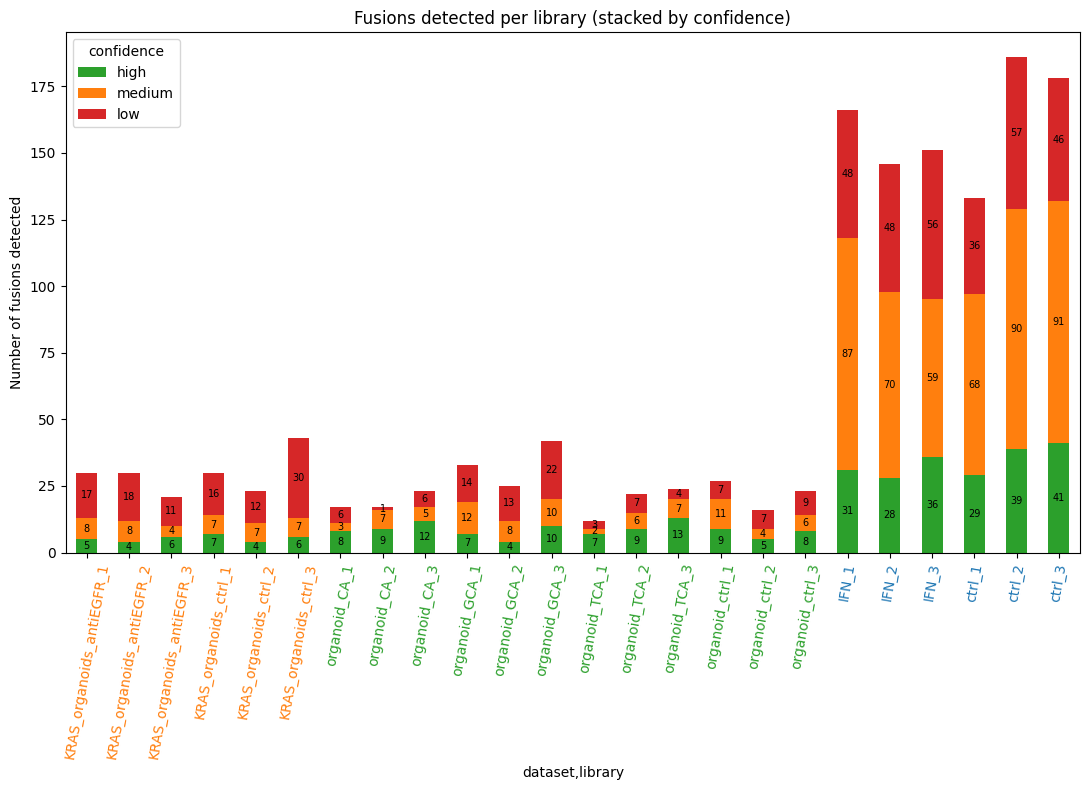

In [79]:
fig, ax = plt.subplots(figsize=(11, 8))

# Colours for the confidence segments (the stacked layers) 
conf_colours = {"high": "tab:green", "medium": "tab:orange", "low": "tab:red"}

# counts is the wide table: rows = (dataset, library), columns = high/medium/low.
# The color list is built in column order so each layer gets the right colour.
counts.plot(
    kind="bar",
    stacked=True,   # stacks the three confidence layers on top of each other.
    ax=ax,
    color=[conf_colours[c] for c in counts.columns])

# Label count inside each segment 
# A stacked pandas plot creates one container per confidence layer
# high, medium, low, loop and label each
for layer in ax.containers:

    # make a label per bar: the number, or "" if count = 0
    # (blank keeps empty segments uncluttered). layer.datavalues = the heights.
    labels = [int(v) if v > 0 else "" for v in layer.datavalues]
    ax.bar_label(layer, labels=labels, label_type="center", fontsize=7, color="black")

# The row index is a (dataset, library) pair; show only the library name on the x-axis.
ax.set_xticklabels([library for (dataset, library) in counts.index], rotation=80)

# Colour each x-tick label by its dataset 
# A colour for each dataset.
dataset_colours = {"mouse_ifn": "tab:blue", "human_bile": "tab:green", "human_antiEGFR": "tab:orange"}

# The dataset for each bar, in the same left-to-right order as the bars.
datasets_in_order = [dataset for (dataset, library) in counts.index]

# Walk through the tick-label objects and their matching dataset together,
# and recolour each label's text.
for tick_label, dataset in zip(ax.get_xticklabels(), datasets_in_order):
    tick_label.set_color(dataset_colours[dataset])

# Axis labels and title.
ax.set_ylabel("Number of fusions detected")
ax.set_title("Fusions detected per library (stacked by confidence)")
confidence_legend = ax.legend(title="confidence", loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(Results_Dir, "fusions_per_library_stacked.png"), dpi=300)
plt.show()

In [80]:
# Save the full collated table and the per library summary as CSV files.
# CSV files open in Excel and are easy to share with collaborators.
fusions.to_csv(os.path.join(Results_Dir, "all_fusions_collated.csv"), index=False)
per_library.to_csv(os.path.join(Results_Dir, "fusions_per_library.csv"), index=False)



1. Are the same fusions found in all replicates of a condition?
   (Each condition was sequenced 3 times = 3 replicates.)
2. Are the same fusions found in treatment vs control?
   (e.g. mouse IFN vs mouse control.)

In [83]:
def calc_replicates(df_condition: str) -> int:
    """
    For all rows in each condition, count how many replicate libraries/samples each fusion_pair appears in.
    """
    n_reps = df_condition["library"].nunique()  # how many replicate libraries (should be 3)

    # For each fusion_pair, count number of DISTINCT libraries it shows up in.
    distinct_sample = (df_condition.groupby("fusion_pair")["library"]
                    .nunique()  # distinct libraries per fusion
                    .reset_index(name="n_replicates")
    )
    distinct_sample["total_replicates"] = n_reps
    return distinct_sample.sort_values("n_replicates", ascending=True)


# Look at every dataset + condition combination and summarise replicates.
summary_rows = []  # collect one summary line per condition
for (dataset, condition), group in fusions.groupby(["dataset", "condition"]):
    distinct_sample = calc_replicates(group)
    n_reps = distinct_sample["total_replicates"].iloc[0]
    summary_rows.append({
        "dataset": dataset,
        "condition": condition,
        "n_replicates": n_reps,
        "unique_fusions": len(distinct_sample),
        "in_all_replicates": int((distinct_sample["n_replicates"] == n_reps).sum()),
        "in_one_replicate_only": int((distinct_sample["n_replicates"] == 1).sum()),
    })

replicates = pd.DataFrame(summary_rows)
replicates.to_csv(os.path.join(Results_Dir, "replicates_summary.csv"), index=False)
print(replicates)

          dataset                condition  n_replicates  unique_fusions  \
0  human_antiEGFR  KRAS_organoids_antiEGFR             3              38   
1  human_antiEGFR      KRAS_organoids_ctrl             3              52   
2      human_bile                       CA             3              30   
3      human_bile                      GCA             3              62   
4      human_bile                      TCA             3              33   
5      human_bile                     ctrl             3              44   
6       mouse_ifn                      IFN             3             242   
7       mouse_ifn                     ctrl             3             269   

   in_all_replicates  in_one_replicate_only  
0                 10                     23  
1                 10                     35  
2                  9                     16  
3                  9                     47  
4                  7                     20  
5                  5                   

Compare the two conditions of each datasets:
- Mouse IFN vs Mouse Contrl
- Human organoid CA/GCA/TCA vs Control
- Human antiEGFR VS Control

In [87]:
def compare_two_conditions(dataset: str, a: str, b: str) -> tuple[set, set, set]:
    """
    Compare fusion pairs between two conditions of one dataset.
    """
    data = fusions[fusions["dataset"] == dataset]
    set_a = set(data[data["condition"] == a]["fusion_pair"])
    set_b = set(data[data["condition"] == b]["fusion_pair"])
    shared = set_a & set_b          # in BOTH
    only_a = set_a - set_b          # in A but NOT B
    only_b = set_b - set_a          # in B but NOT A
    print(f"[{dataset}] {a} vs {b}")
    print(f"  {a}: {len(set_a)} unique fusions")
    print(f"  {b}: {len(set_b)} unique fusions")
    print(f"  shared in both: {len(shared)}")
    print(f"  only in {a}: {len(only_a)}")
    print(f"  only in {b}: {len(only_b)}")
    return shared, only_a, only_b


def compare_conditions(dataset: str, conditions: list[str]) -> tuple[set, dict[str,set]]:
    """
    Compare ANY number of conditions of one dataset.
    `conditions` is a list, e.g. ["CA", "GCA", "TCA", "ctrl"].
    """
    data = fusions[fusions["dataset"] == dataset]
    
    # Build one set of fusion pairs per condition, stored in a dictionary.
    sets = {c: set(data[data["condition"] == c]["fusion_pair"]) for c in conditions}

    # set.intersection(*...) = fusions present in EVERY condition.
    shared = set.intersection(*sets.values())

    # For each condition, subtract the union of all the OTHER conditions.
    unique = {}
    for c in conditions:
        others = set().union(*[sets[o] for o in conditions if o != c])
        unique[c] = sets[c] - others
    print(f"[{dataset}] comparing: {', '.join(conditions)}")

    for c in conditions:
        print(f"  {c}: {len(sets[c])} unique fusions, {len(unique[c])} found ONLY in {c}")
    print(f"  shared by ALL: {len(shared)}")
    return shared, unique


# Human bile salts: 4 conditions at once
bile_shared, bile_unique = compare_conditions("human_bile", ["CA", "GCA", "TCA", "ctrl"])
print("\nExamples of condition unique fusions:", sorted(unique)[:10])

# Print a few example fusions unique to each condition.
for condition in ["CA", "GCA", "TCA", "ctrl"]:
    print(f"\nExamples of {condition}-only fusions:", sorted(bile_unique[condition])[:10])

# Mouse: IFN-treated vs control
mouse_shared, ifn_only, mouse_control_only = compare_two_conditions("mouse_ifn", "IFN", "ctrl")
print("\nExamples of IFN-only fusions:", sorted(ifn_only)[:10])

# Human: anti-EGFR vs control  (condition is "antiEGFR", not the long library prefix)
EGFR_shared, antiEGFR_only, EGFR_control_only = compare_two_conditions("human_antiEGFR", "KRAS_organoids_antiEGFR", "ctrl")
print("\nExamples of antiEGFR-only fusions:", sorted(antiEGFR_only)[:10])





[human_bile] comparing: CA, GCA, TCA, ctrl
  CA: 30 unique fusions, 11 found ONLY in CA
  GCA: 62 unique fusions, 45 found ONLY in GCA
  TCA: 33 unique fusions, 12 found ONLY in TCA
  ctrl: 44 unique fusions, 24 found ONLY in ctrl
  shared by ALL: 13

Examples of condition unique fusions: ['CA', 'GCA', 'TCA', 'ctrl']

Examples of CA-only fusions: ['AHDC1::HIVEP3', 'B3GALNT2::MTA2', 'CAMKMT::PIGF', 'ENSG00000213981::MYO3B', 'ENSG00000295365::KAT7P1', 'ENSG00000296907::SULT1C3', 'RC3H1::COP1', 'SLC35E2B::GPR35', 'TRA2B::LPP', 'UBE2G2::AGPAT3']

Examples of GCA-only fusions: ['ARSD::XG', 'BSG::ENSG00000278996', 'CLDN12::YLPM1', 'ENSG00000225339::MYL6B', 'ENSG00000232006::COPS4', 'ENSG00000273308::PDCD6', 'ENSG00000289750::LSM3', 'ENSG00000290683::ZNF670-ZNF695', 'ENSG00000290683::ZNF695', 'ENSG00000296907::PDS5B']

Examples of TCA-only fusions: ['ANKRD27::ENSG00000267059', 'ANKRD27::MBD3', 'BTBD2::SBNO2', 'ENSG00000271793::RNF149', 'GUSBP11::GUSBP11', 'LYPD6B::YTHDC1', 'NPIPB5::ENSG000002